In [1]:
# Code cell
import os, re
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
from scipy.sparse import issparse
import matplotlib.pyplot as plt
import omicverse as ov

# 路径与文件
DATA_ROOT = "/mnt/c/Users/Future/OneDrive/UC_project/scRNA-seq_data"
ANNO_DIR  = os.path.join(DATA_ROOT, "06_annotation/Merge"); os.makedirs(ANNO_DIR, exist_ok=True)
FIG_DIR   = os.path.join(ANNO_DIR, "figs");          os.makedirs(FIG_DIR,  exist_ok=True)

IN_PATH   = os.path.join(DATA_ROOT, "06_annotation/L1/L1_lineage_annotated.h5ad")
OUT_H5AD  = os.path.join(ANNO_DIR, "L3_annotated.h5ad")

/home/future/miniconda3/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
adata = sc.read_h5ad(IN_PATH)
adata

AnnData object with n_obs × n_vars = 374507 × 11743
    obs: 'GSM', 'group', 'GSE', 'leiden_scVI_0.2', 'L1lin_marker', 'L1lin_score', 'L1lin_gpt', 'L1_lineage', 'L1lin_conf'
    var: 'mt'
    uns: 'GSE_colors', 'L1_lineage_colors', 'REFERENCE_MANU', 'leiden_scVI_0.2', 'leiden_scVI_0.2_colors', 'log1p', 'neighbors', 'rank_genes_groups', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities'

In [3]:
import pandas as pd

# 1. 定义 CSV 文件路径
csv_path = "/mnt/c/Users/Future/OneDrive/UC_project/scRNA-seq_data/06_annotation/Merge/all_merged_annotation.csv"

# 2. 读取 CSV 文件
# index_col=0 表示将第一列（通常是 Barcode/Unnamed: 0）作为 DataFrame 的索引
annotation_df = pd.read_csv(csv_path, index_col=0)

# 检查一下读取是否正确，确保 index 是您的细胞 barcodes
print("CSV 前几行预览：")
print(annotation_df.head())

# 3. 提取您需要的 'L3' 列
# 这样可以防止把 CSV 里其他的列（如 GSM, group）重复合并进 adata
l3_series = annotation_df['L3']

# 4. 将 L3 列合并到 adata.obs 中
# 使用 join 或直接赋值都可以，Pandas 会根据 index (barcode) 自动对齐
# how='left' 保证以 adata 为主，如果 CSV 里缺少某些细胞，对应位置会填 NaN，不会报错
adata.obs = adata.obs.join(l3_series, how='left')

# 或者使用更简单的方式（如果确定没有重复列名）：
# adata.obs['L3'] = annotation_df['L3'] 
# (注意：这种直接赋值方式，如果 annotation_df 包含 adata 中没有的细胞，那些细胞会被忽略；
#  如果 adata 中有 annotation_df 没有的细胞，对应值会变成 NaN)

# 5. 检查合并结果
print("\n合并后 adata.obs 的列名：")
print(adata.obs.columns)

print("\n合并后 L3 列的前几行：")
print(adata.obs['L3'].head())

# 6. (可选) 检查是否有未匹配到的细胞 (NaN)
na_count = adata.obs['L3'].isna().sum()
print(f"\n未匹配到 L3 注释的细胞数量: {na_count}")

CSV 前几行预览：
                                       L3
GSM8980878_UC68_CELL478_N2        Naive T
GSM8980878_UC68_CELL572_N2       T_Stress
GSM8980878_UC68_CELL1670_N2   CD4+ Memory
GSM8980878_UC68_CELL2132_N1      CD8+ Tem
GSM8980878_UC68_CELL4295_N2  Contaminants

合并后 adata.obs 的列名：
Index(['GSM', 'group', 'GSE', 'leiden_scVI_0.2', 'L1lin_marker', 'L1lin_score',
       'L1lin_gpt', 'L1_lineage', 'L1lin_conf', 'L3'],
      dtype='object')

合并后 L3 列的前几行：
GSM8980878_UC68_CELL6_N4      Fibroblast
GSM8980878_UC68_CELL10_N2    Active_Glia
GSM8980878_UC68_CELL14_N2     Fibroblast
GSM8980878_UC68_CELL20_N5     Fibroblast
GSM8980878_UC68_CELL21_N3     Fibroblast
Name: L3, dtype: object

未匹配到 L3 注释的细胞数量: 0


In [4]:
adata

AnnData object with n_obs × n_vars = 374507 × 11743
    obs: 'GSM', 'group', 'GSE', 'leiden_scVI_0.2', 'L1lin_marker', 'L1lin_score', 'L1lin_gpt', 'L1_lineage', 'L1lin_conf', 'L3'
    var: 'mt'
    uns: 'GSE_colors', 'L1_lineage_colors', 'REFERENCE_MANU', 'leiden_scVI_0.2', 'leiden_scVI_0.2_colors', 'log1p', 'neighbors', 'rank_genes_groups', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities'

In [5]:
adata.obs["L3"].value_counts()

L3
Fibroblast          95479
Early_Absorptive    29774
Plasma IgA          25079
Low Quality         21789
Absorptive          21075
Plasma Stressed     20401
Pericyte_SMC        13870
Contaminants        13735
T_Stress            13019
CD4+ Memory         12068
CD8+ Tem            11008
Plasma IgG          10942
Naive T              8704
CD8+ Teff            8612
Stem_TA_prolif       7424
Treg                 7340
Naive B              6565
Active_Glia          5950
Goblet               5683
Tex                  5419
Endothelial          5255
CD8+ Trm             4580
B_Stress             4466
NK                   3485
Mast                 2569
GC B                 2504
Glia                 1733
Mac Resident         1529
Mono Classical       1232
Tuft                  899
Mac Inflammatory      823
Mac Activated         628
Prolif Myeloid        469
DC Mature             215
Mac Remodeling         99
pDC                    85
Name: count, dtype: int64

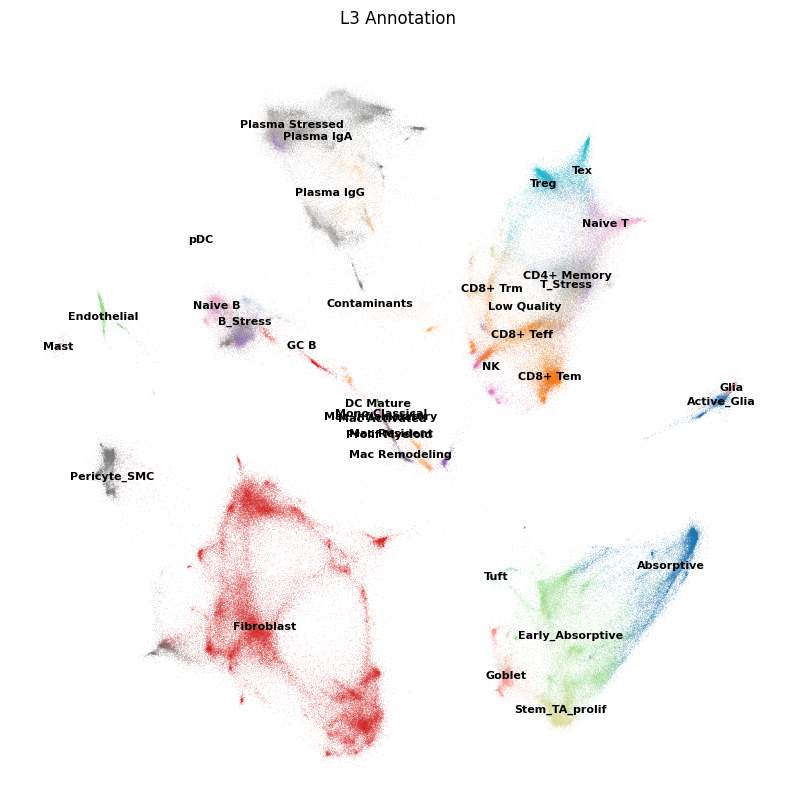

In [10]:
# 1. 创建指定大小的画布 (例如 10x10 英寸)
fig, ax = plt.subplots(figsize=(10, 10))

# 2. 将 ax 传入 sc.pl.umap
sc.pl.umap(
    adata, 
    color='L3', 
    title='L3 Annotation', 
    frameon=False, 
    legend_loc='on data', 
    legend_fontsize=8,
    palette='tab20',
    ax=ax,          # 关键：指定在这个 ax 上画图
    show=False      # 关键：先不显示，以便后面继续调整或保存
)

# 3. 保存高分辨率图片
# dpi=300 设置分辨率，bbox_inches='tight' 防止边缘被裁剪
plt.savefig("/mnt/c/Users/Future/OneDrive/UC_project/scRNA-seq_data/06_annotation/Merge/L3_Annotation_UMAP.png", dpi=900, bbox_inches='tight')

# 4. 显示图片
plt.show()

In [11]:
adata.write_h5ad(OUT_H5AD, compression="gzip")